# Spam Email Detection System

In [21]:
# Load Data

import sys
sys.path.append('../SRC')
from data_loader import load_data

path = '../Data/Raw/emails.csv'

df = load_data(path)

In [22]:
# Libraries Import

import pandas as pd

## First 5 row of data

In [23]:
df.head()

,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1


## Last 5 Rows of Data

In [24]:
df.tail()

,text,spam
5723,Subject: re : research and development charges...,0
5724,"Subject: re : receipts from visit jim , than...",0
5725,Subject: re : enron case study update wow ! a...,0
5726,"Subject: re : interest david , please , call...",0
5727,Subject: news : aurora 5 . 2 update aurora ve...,0


## Dataset dimension

In [25]:
df.shape

(5728, 2)

In [26]:
print(df.groupby('spam').size())

spam
0    4360
1    1368
dtype: int64


<Axes: xlabel='spam'>

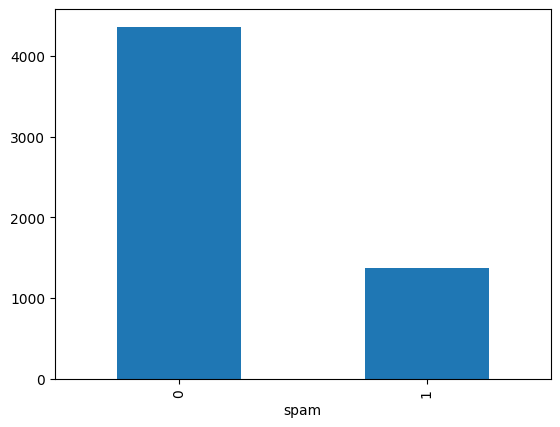

In [27]:
df['spam'].value_counts().plot(kind='bar')

## Resampling

In [28]:
from sklearn.utils import resample

# Separate classes
not_spam = df[df['spam'] == 0]
spam = df[df['spam'] == 1]


undersample = resample(
    not_spam,
    replace=False,
    n_samples=1368,
    random_state=42
)

balance_df = pd.concat ([undersample, spam])

<Axes: xlabel='spam'>

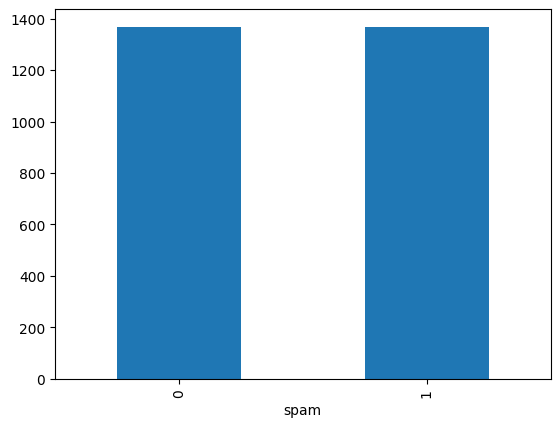

In [29]:
balance_df['spam'].value_counts().plot(kind='bar')

## NLP 

### Preprocessing

In [30]:
from preprocessor import convert_to_clean_text

In [31]:
balance_df['text'] = balance_df['text'].fillna('')
final_df = convert_to_clean_text(balance_df, ['text'])

In [32]:
final_df.head()

,text,spam
1547,subject: interview schedule for jinbaek kim i...,0
2730,"subject: re : wednesday meeting eric , i thi...",0
4843,subject: re : london research group i ' d do ...,0
2856,"subject: re : congratulations vince , thanks ...",0
3804,subject: osman sezgen steve kromer is request...,0


### VECTORIZATION

In [42]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorize = TfidfVectorizer()
x = df[['text']]
Vector_X = vectorize.fit_transform(x)


In [39]:
# Data Modeling
from sklearn.model_selection import train_test_split
y = df['spam'].values
X_train, y_train, X_test, y_test = train_test_split(Vector_X, y, test_size=0.3, random_state=42)



### Model Implementation

In [40]:
# Importing Models
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import MultinomialNB


In [41]:
m1 = RandomForestClassifier()
m1.fit(X_train,y_train)

m2 = DecisionTreeClassifier()
m2.fit (X_train,y_train)

m3 = MultinomialNB()
m3.fit (X_train,y_train)

ValueError: sparse multilabel-indicator for y is not supported.